In [45]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [46]:
import torch
import matplotlib.pyplot as plt

from utils.model import build_resnet50
from utils.dataloaders import create_dataloaders
from utils.checkpoint import load_checkpoint

from utils.explainability import (
    generate_gradcam,
    tensor_to_image,
    overlay_heatmap
)

In [47]:
if torch.backends.mps.is_available():
    device = torch.device("mps")

elif torch.cuda.is_available():
    device = torch.device("cuda")

else:
    device = torch.device("cpu")

print(device)

mps


In [48]:
dataset_path = "../datasets/COVID-19_Radiography_Dataset"

(
    train_loader,
    val_loader,
    test_loader,
    train_df,
    val_df,
    test_df
) = create_dataloaders(
    dataset_path=dataset_path,
    batch_size=1
)

In [49]:
model = build_resnet50()

model = load_checkpoint(
    model,
    "../checkpoints/best_resnet50.pth",
    device
)

model = model.to(device)   # <-- IMPORTANT

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [50]:
images, labels = next(iter(test_loader))

images = images.to(device)

labels = labels.to(device)

print(labels)

tensor([1], device='mps:0')


In [51]:
target_layers = [model.layer4[-1]]

grayscale_cam = generate_gradcam(
    model=model,
    input_tensor=images,
    target_layers=target_layers
)

print(grayscale_cam.shape)

(224, 224)


In [52]:
original_image = tensor_to_image(images)

print(original_image.shape)

(224, 224, 3)


In [53]:
gradcam_image = overlay_heatmap(
    original_image,
    grayscale_cam
)

In [54]:
from pathlib import Path

save_dir = Path("../figures/gradcam")
save_dir.mkdir(parents=True, exist_ok=True)

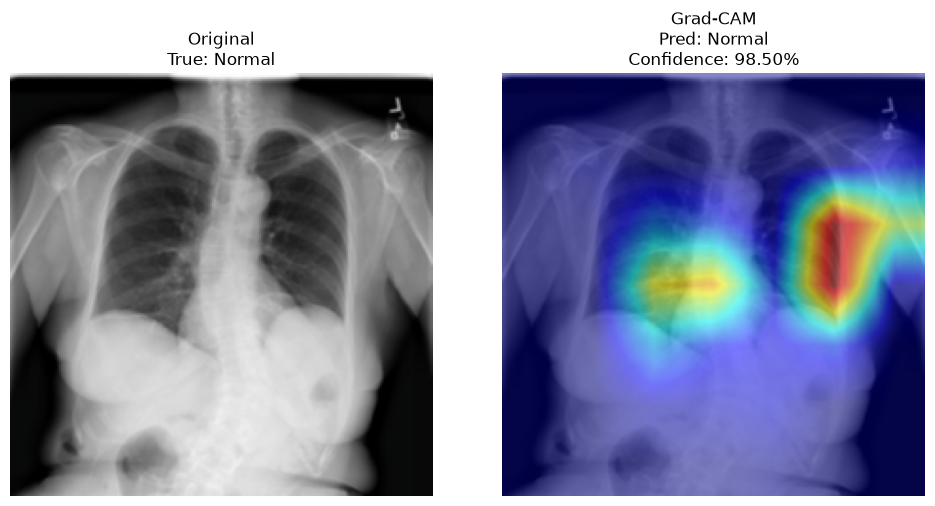

Figure saved to: ../figures/gradcam/Normal_pred_Normal.png


In [55]:
from pathlib import Path

# Create folder if it doesn't exist
save_dir = Path("../figures/gradcam")
save_dir.mkdir(parents=True, exist_ok=True)

# Filename
filename = f"{class_names[labels.item()]}_pred_{class_names[prediction.item()]}.png"

# Plot
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title(f"Original\nTrue: {class_names[labels.item()]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gradcam_image)
plt.title(
    f"Grad-CAM\nPred: {class_names[prediction.item()]}\n"
    f"Confidence: {confidence.item()*100:.2f}%"
)
plt.axis("off")

plt.tight_layout()

# Save figure
plt.savefig(
    save_dir / filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {save_dir / filename}")

In [56]:
# Class labels
class_names = {
    0: "COVID",
    1: "Normal",
    2: "Lung Opacity",
    3: "Viral Pneumonia"
}

# Predict
with torch.no_grad():

    outputs = model(images)

    probabilities = torch.softmax(outputs, dim=1)

    confidence, prediction = torch.max(probabilities, 1)

# Display results
print(f"True Class      : {class_names[labels.item()]}")
print(f"Predicted Class : {class_names[prediction.item()]}")
print(f"Confidence      : {confidence.item()*100:.2f}%")

True Class      : Normal
Predicted Class : Normal
Confidence      : 98.50%


In [57]:
correct_samples = {}

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        prediction = outputs.argmax(dim=1)

        true_label = labels.item()
        pred_label = prediction.item()

        # Keep only correctly classified samples
        if true_label == pred_label and true_label not in correct_samples:

            correct_samples[true_label] = (
                images.cpu(),
                labels.cpu()
            )

        # Stop once we have one sample from each class
        if len(correct_samples) == 4:
            break

print("Collected samples for classes:")
for key in correct_samples:
    print(f"{key} -> {class_names[key]}")

Collected samples for classes:
1 -> Normal
0 -> COVID
3 -> Viral Pneumonia
2 -> Lung Opacity


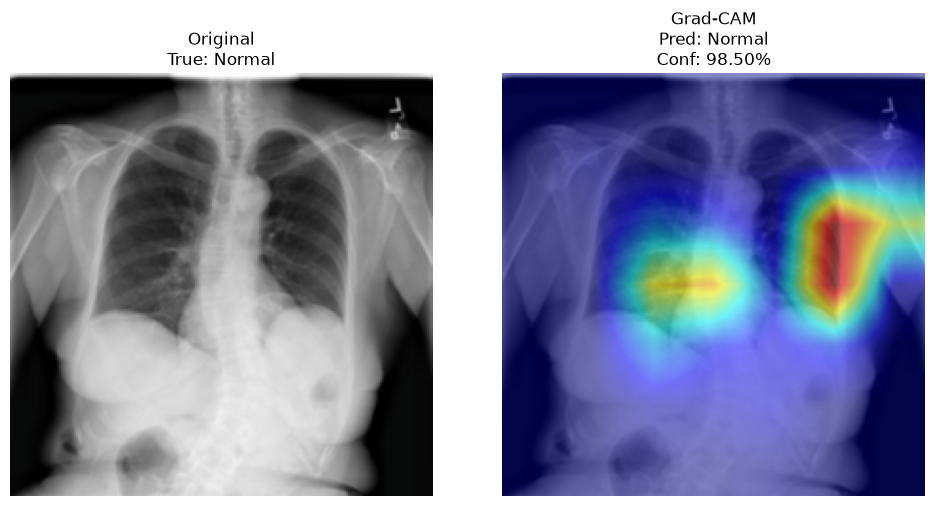

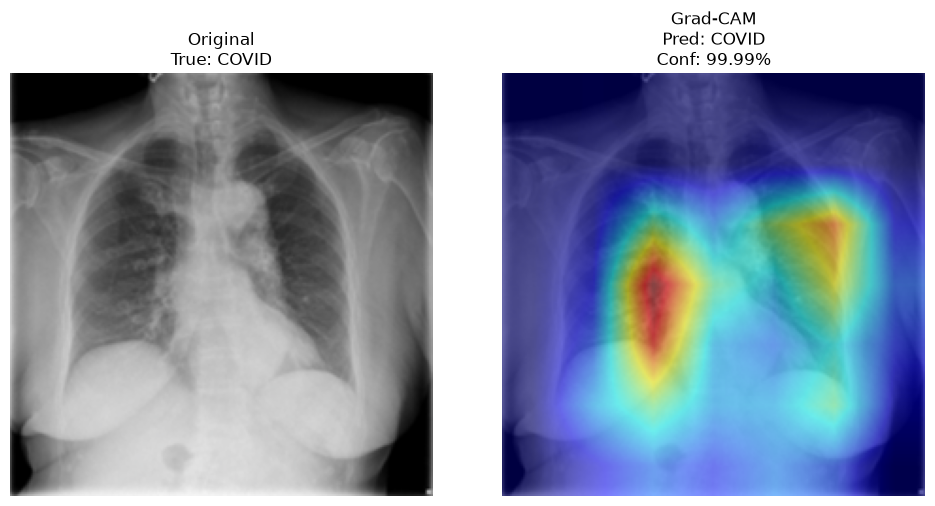

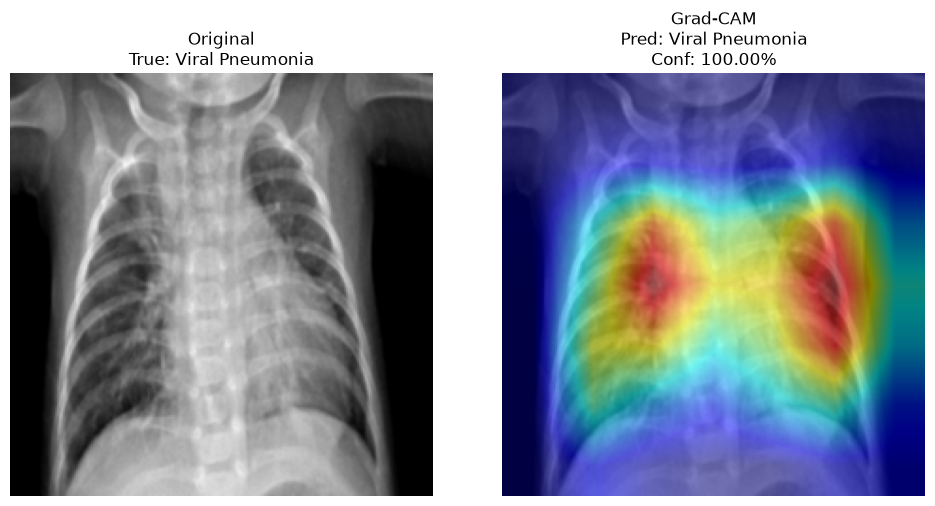

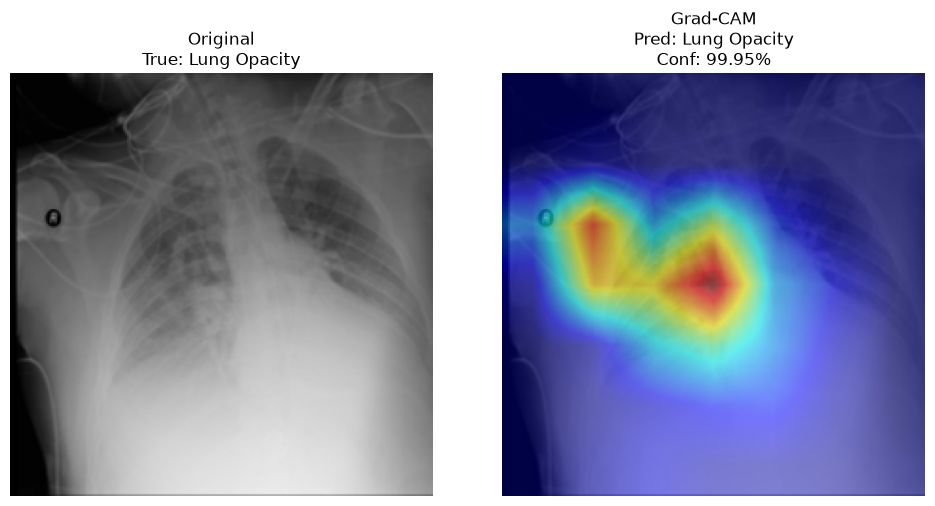

All Grad-CAM figures saved successfully.


In [58]:
from pathlib import Path

save_dir = Path("../figures/gradcam")
save_dir.mkdir(parents=True, exist_ok=True)

target_layers = [model.layer4[-1]]

for class_id, (images, labels) in correct_samples.items():

    images = images.to(device)

    # Prediction
    with torch.no_grad():
        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, prediction = torch.max(probabilities, 1)

    # Grad-CAM
    grayscale_cam = generate_gradcam(
        model=model,
        input_tensor=images,
        target_layers=target_layers
    )

    original_image = tensor_to_image(images)
    gradcam_image = overlay_heatmap(original_image, grayscale_cam)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(original_image)
    plt.title(f"Original\nTrue: {class_names[class_id]}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(gradcam_image)
    plt.title(
        f"Grad-CAM\nPred: {class_names[prediction.item()]}\n"
        f"Conf: {confidence.item()*100:.2f}%"
    )
    plt.axis("off")

    plt.tight_layout()

    filename = (
        f"true_{class_names[class_id].replace(' ', '_')}"
        f"_pred_{class_names[prediction.item()].replace(' ', '_')}.png"
    )

    plt.savefig(
        save_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

print("All Grad-CAM figures saved successfully.")